In [1]:
import math
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
def generate_sine_data(n_samples=1024):
    x = 2.0 * math.pi * torch.rand(n_samples, 1)
    y = torch.sin(x)
    data = torch.cat([x, y], dim=1)
    return data


def generate_noisy_curve_data(n_samples=1024, noise_std=0.08):
    x = 2.0 * math.pi * torch.rand(n_samples, 1)
    epsilon = noise_std * torch.randn(n_samples, 1)
    y = torch.sin(2 * x) + 0.3 * torch.cos(5 * x) + epsilon
    data = torch.cat([x, y], dim=1)
    return data


def create_loader(data, batch_size=32):
    labels = torch.zeros(data.shape[0], 1)
    dataset = TensorDataset(data, labels)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return loader

In [4]:
class GeneratorBaseline(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, z):
        return self.model(z)


class DiscriminatorBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


class GeneratorModified(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.model(z)


class DiscriminatorModified(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [5]:
def train_gan(
    generator,
    discriminator,
    train_loader,
    latent_dim=2,
    lr=0.001,
    num_epochs=1200,
    print_every=200
):
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    loss_function = nn.BCELoss()

    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)

    generator_losses = []
    discriminator_losses = []

    for epoch in range(num_epochs):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for real_samples, _ in train_loader:
            real_samples = real_samples.to(device)
            batch_size = real_samples.shape[0]

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            latent_samples = torch.randn(batch_size, latent_dim, device=device)
            generated_samples = generator(latent_samples)

            all_samples = torch.cat((real_samples, generated_samples.detach()), dim=0)
            all_labels = torch.cat((real_labels, fake_labels), dim=0)

            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            latent_samples = torch.randn(batch_size, latent_dim, device=device)

            generator.zero_grad()
            generated_samples = generator(latent_samples)
            output_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_generated, real_labels)
            loss_generator.backward()
            optimizer_generator.step()

            epoch_d_loss += loss_discriminator.item()
            epoch_g_loss += loss_generator.item()

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        discriminator_losses.append(avg_d_loss)
        generator_losses.append(avg_g_loss)

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}] "
                f"Loss D: {avg_d_loss:.4f} | Loss G: {avg_g_loss:.4f}"
            )

    return generator, discriminator, generator_losses, discriminator_losses

In [6]:
def generate_samples(generator, n_samples=1000, latent_dim=2):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim, device=device)
        generated = generator(z).cpu()
    return generated


def plot_real_data(data, title):
    data_np = data.numpy()

    plt.figure(figsize=(6, 4))
    plt.scatter(data_np[:, 0], data_np[:, 1], s=10, alpha=0.7)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()


def plot_real_vs_generated(real_data, generated_data, title):
    real_np = real_data.numpy()
    gen_np = generated_data.numpy()

    plt.figure(figsize=(7, 5))
    plt.scatter(real_np[:, 0], real_np[:, 1], s=10, alpha=0.5, label="Real")
    plt.scatter(gen_np[:, 0], gen_np[:, 1], s=10, alpha=0.5, label="Generated")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_losses(generator_losses, discriminator_losses, title):
    plt.figure(figsize=(7, 4))
    plt.plot(generator_losses, label="Generator loss")
    plt.plot(discriminator_losses, label="Discriminator loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

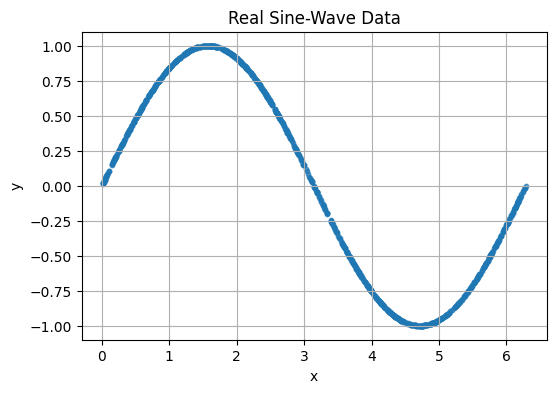

Epoch [200/1200] Loss D: 0.6630 | Loss G: 0.7328
Epoch [400/1200] Loss D: 0.6854 | Loss G: 0.7331
Epoch [600/1200] Loss D: 0.6596 | Loss G: 0.8236
Epoch [800/1200] Loss D: 0.6364 | Loss G: 0.8410
Epoch [1000/1200] Loss D: 0.6290 | Loss G: 0.8110
Epoch [1200/1200] Loss D: 0.6240 | Loss G: 0.8273


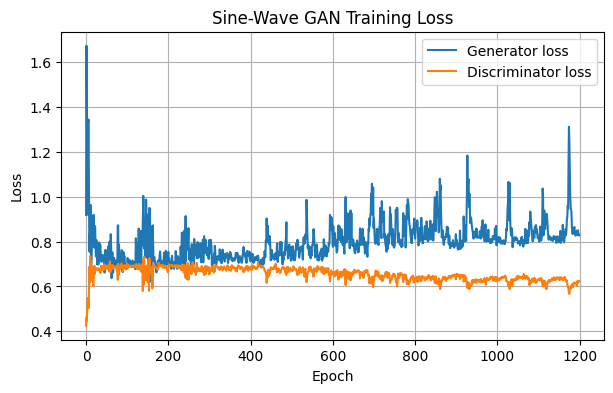

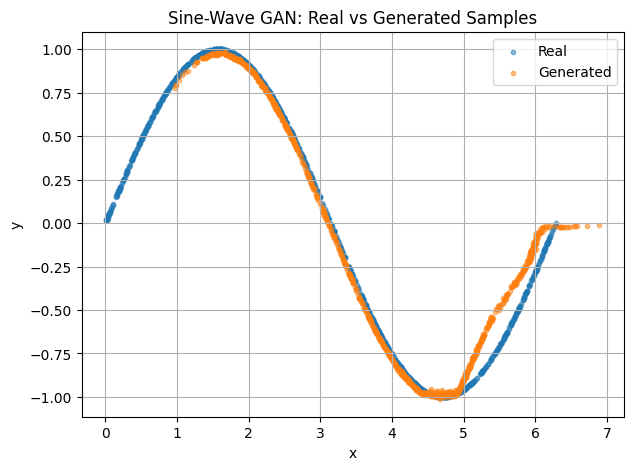

In [7]:
sine_data = generate_sine_data(n_samples=1024)
sine_loader = create_loader(sine_data, batch_size=32)

plot_real_data(sine_data, "Real Sine-Wave Data")

sine_generator = GeneratorBaseline(latent_dim=2)
sine_discriminator = DiscriminatorBaseline()

sine_generator, sine_discriminator, sine_g_losses, sine_d_losses = train_gan(
    generator=sine_generator,
    discriminator=sine_discriminator,
    train_loader=sine_loader,
    latent_dim=2,
    lr=0.001,
    num_epochs=1200,
    print_every=200
)

sine_generated = generate_samples(sine_generator, n_samples=1000, latent_dim=2)

plot_losses(
    sine_g_losses,
    sine_d_losses,
    "Sine-Wave GAN Training Loss"
)

plot_real_vs_generated(
    sine_data,
    sine_generated,
    "Sine-Wave GAN: Real vs Generated Samples"
)

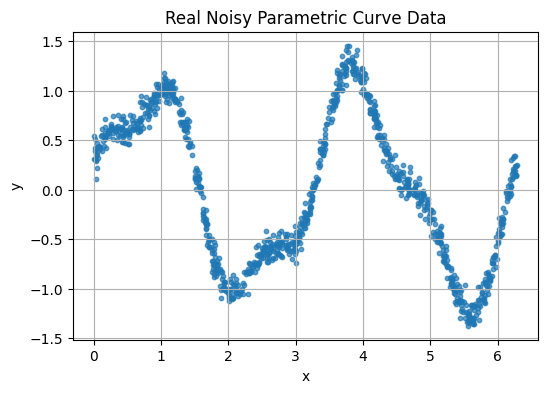

Epoch [200/1200] Loss D: 0.6481 | Loss G: 0.8543
Epoch [400/1200] Loss D: 0.6758 | Loss G: 0.7755
Epoch [600/1200] Loss D: 0.6803 | Loss G: 0.7325
Epoch [800/1200] Loss D: 0.6799 | Loss G: 0.7804
Epoch [1000/1200] Loss D: 0.6856 | Loss G: 0.7557
Epoch [1200/1200] Loss D: 0.6823 | Loss G: 0.7630


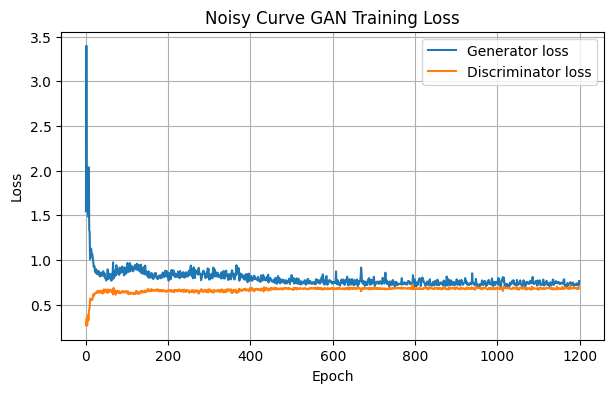

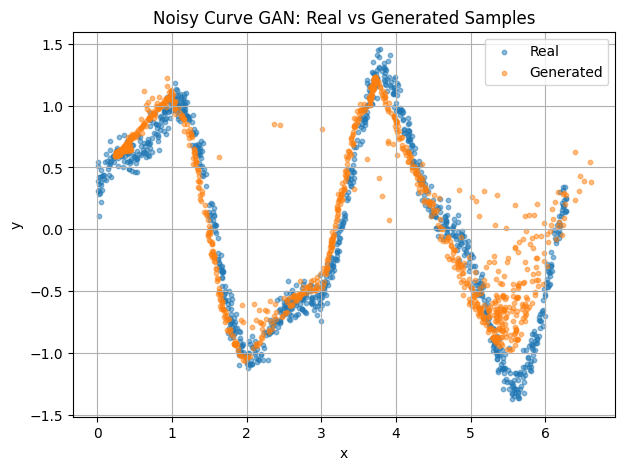

In [8]:
curve_data = generate_noisy_curve_data(n_samples=1024, noise_std=0.08)
curve_loader = create_loader(curve_data, batch_size=32)

plot_real_data(curve_data, "Real Noisy Parametric Curve Data")

curve_generator = GeneratorBaseline(latent_dim=2)
curve_discriminator = DiscriminatorBaseline()

curve_generator, curve_discriminator, curve_g_losses, curve_d_losses = train_gan(
    generator=curve_generator,
    discriminator=curve_discriminator,
    train_loader=curve_loader,
    latent_dim=2,
    lr=0.001,
    num_epochs=1200,
    print_every=200
)

curve_generated = generate_samples(curve_generator, n_samples=1000, latent_dim=2)

plot_losses(
    curve_g_losses,
    curve_d_losses,
    "Noisy Curve GAN Training Loss"
)

plot_real_vs_generated(
    curve_data,
    curve_generated,
    "Noisy Curve GAN: Real vs Generated Samples"
)

Epoch [200/1200] Loss D: 0.7145 | Loss G: 0.7072
Epoch [400/1200] Loss D: 0.6926 | Loss G: 0.7414
Epoch [600/1200] Loss D: 0.6891 | Loss G: 0.7248
Epoch [800/1200] Loss D: 0.6904 | Loss G: 0.6851
Epoch [1000/1200] Loss D: 0.6605 | Loss G: 0.6545
Epoch [1200/1200] Loss D: 0.6475 | Loss G: 0.7964


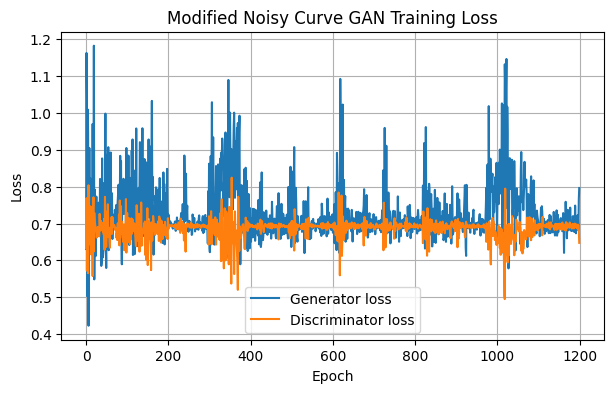

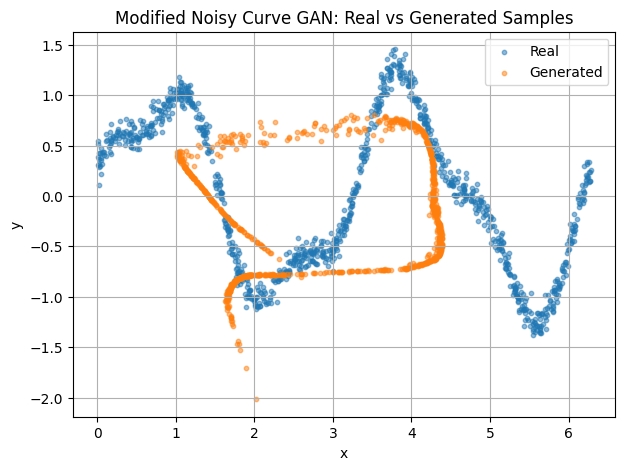

In [9]:
modified_generator = GeneratorModified(latent_dim=2)
modified_discriminator = DiscriminatorModified()

modified_generator, modified_discriminator, modified_g_losses, modified_d_losses = train_gan(
    generator=modified_generator,
    discriminator=modified_discriminator,
    train_loader=curve_loader,
    latent_dim=2,
    lr=0.0008,
    num_epochs=1200,
    print_every=200
)

modified_generated = generate_samples(modified_generator, n_samples=1000, latent_dim=2)

plot_losses(
    modified_g_losses,
    modified_d_losses,
    "Modified Noisy Curve GAN Training Loss"
)

plot_real_vs_generated(
    curve_data,
    modified_generated,
    "Modified Noisy Curve GAN: Real vs Generated Samples"
)

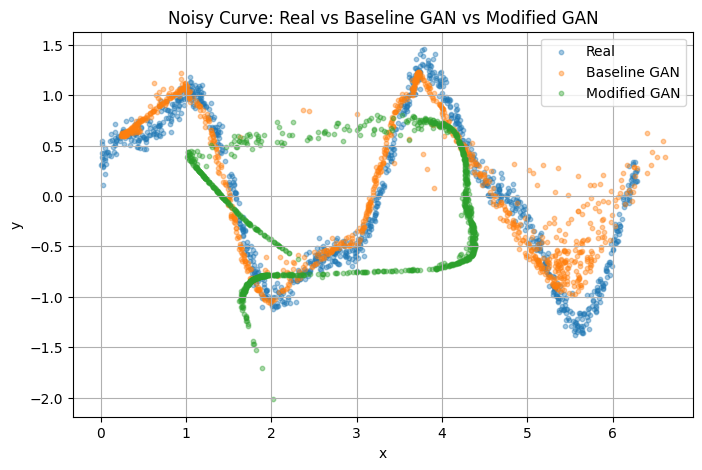

In [10]:
curve_np = curve_data.numpy()
baseline_np = curve_generated.numpy()
modified_np = modified_generated.numpy()

plt.figure(figsize=(8, 5))
plt.scatter(curve_np[:, 0], curve_np[:, 1], s=10, alpha=0.4, label="Real")
plt.scatter(baseline_np[:, 0], baseline_np[:, 1], s=10, alpha=0.4, label="Baseline GAN")
plt.scatter(modified_np[:, 0], modified_np[:, 1], s=10, alpha=0.4, label="Modified GAN")
plt.title("Noisy Curve: Real vs Baseline GAN vs Modified GAN")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()